[Link](https://huggingface.co/datasets/m-aliabbas/idrak_timit_subsample)

In [ ]:
from datasets import load_dataset # pip install datasets


dataset = load_dataset(
    "m-aliabbas/idrak_timit_subsample",
    split="train" # only get train dataset
)


c:\Users\HuyenDT\source\repos\sttproject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
print(dataset.cache_files)

[{'filename': 'C:\\Users\\HuyenDT\\.cache\\huggingface\\datasets\\m-aliabbas___idrak_timit_subsample\\default\\0.0.0\\2a386a72d74bfa338c6c2841a3bc4eae4b4ed690\\idrak_timit_subsample-train.arrow'}]


In [24]:
dataset

Dataset({
    features: ['audio', 'transcription'],
    num_rows: 1296
})

In [ ]:
# pip install torchcodec  => read audio file, convert into array (waveform) and return sampling_rate
# pip install torch torchaudio => PyTorch 
it = iter(dataset)
data = next(it) # first item of iter 

In [ ]:
#data = next(it)
audio = data["audio"]["array"]
sample_rate = data["audio"]["sampling_rate"]
transcript = data["transcription"]
print(audio.shape) # audio has 35840 values 
print(sample_rate) # there are 16000 float values to represent one second of audio 
print("Audio lengths: ", audio.size / sample_rate)
print(transcript)

(58061,)
16000
Audio lengths:  3.6288125
he picked up nine pairs of socks for each brother


- audio is just a seq of amplitude values across time
- The sampling rate basically means how many amplitudes were captured for 1 sec of audio 

In [34]:
from IPython.display import Audio 
Audio(audio, rate=sample_rate)

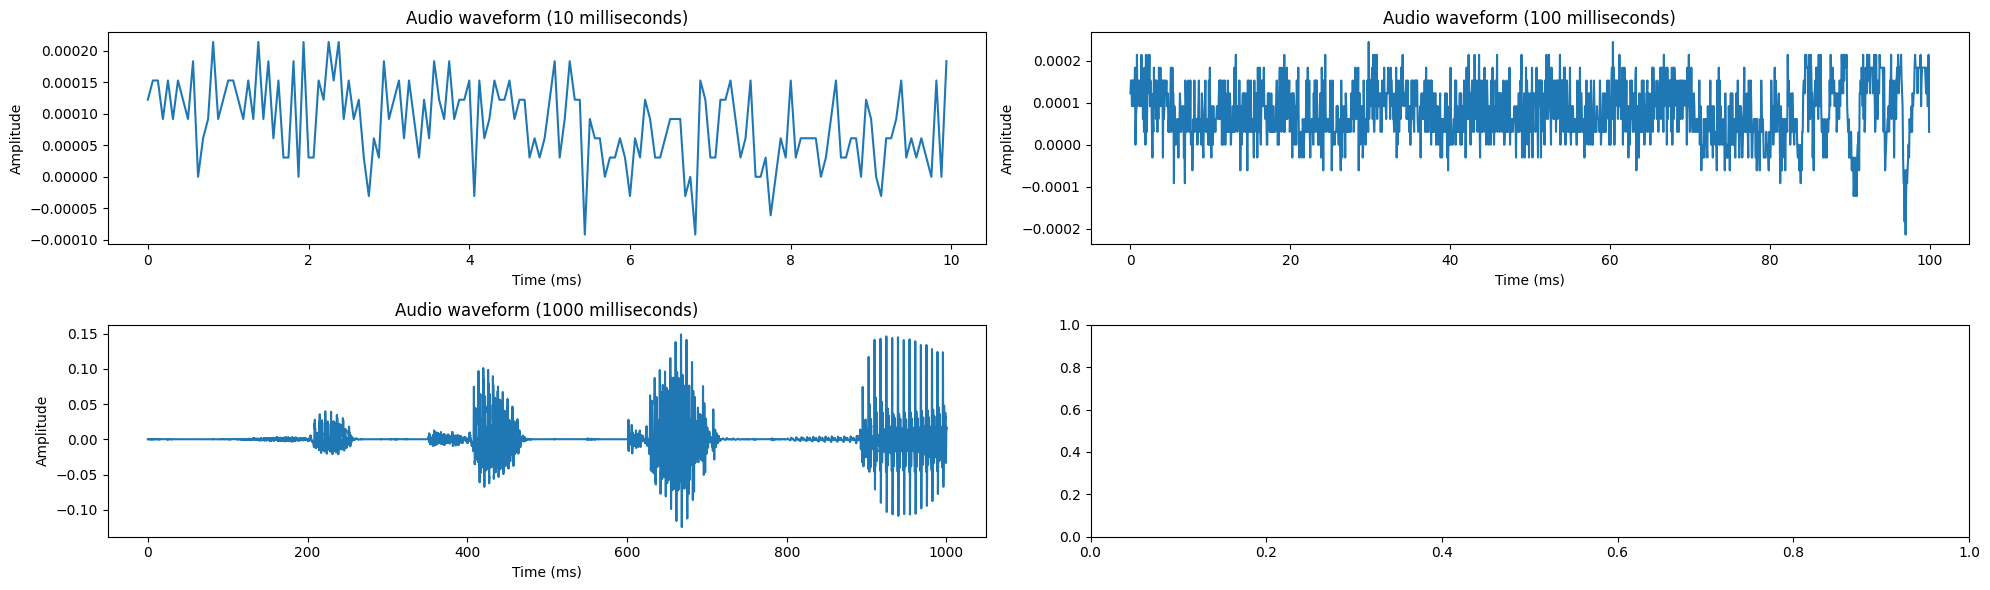

In [35]:
import matplotlib.pyplot as plt 
import numpy as np 

def drawWaveform (audioLen, axes): 
    start_time_ms = 0 
    end_time_ms = audioLen # milliseconds: 10, 100, 1000: this is how amplitude values look like for the first 10, 100... miliseconds

    start_idx = int(start_time_ms * sample_rate / 1000) # sample_rate/sec => need to divide by 1000
    end_idx = int(end_time_ms * sample_rate / 1000)

    audio_np = audio[start_idx: end_idx]

    # Create time axis in milliseconds
    time_ms = np.arange(len(audio_np)) * (1000/sample_rate)

    axes.plot(time_ms, audio_np)
    axes.set_xlabel('Time (ms)')
    axes.set_ylabel('Amplitude')
    axes.set_title(f"Audio waveform ({audioLen} milliseconds)")
    # plt.show()

fig, axes = plt.subplots(2, 2, figsize=(20, 6))
axes = axes.flatten() 

drawWaveform(10, axes[0])
drawWaveform(100, axes[1])
drawWaveform(1000, axes[2])
plt.tight_layout()

###  Text Tokenization

In [ ]:
from tokenizers import Tokenizer, models, pre_tokenizers, decoders

def get_tokenizer(save_path = "tokenizer.json"): 
    tokenizer = Tokenizer(models.BPE()) # Byte Pair Encoding: subword tokenization.
    tokenizer.add_special_tokens(["_"]) # blank token 
    tokenizer.add_tokens(list("ABCDEFGHIJKLMNOPQRSTUVWXYZ '"))

    tokenizer.pre_tokenizer =pre_tokenizers.ByteLevel() 
    tokenizer.decoder = decoders.ByteLevel() 
    tokenizer.blank_token = tokenizer.token_to_id(" ")
    tokenizer.save(save_path)

    return tokenizer


In [57]:
tokenizer = get_tokenizer() 

In [58]:
sorted(tokenizer.get_vocab().items(), key=lambda x: x[1])

[('_', 0),
 ('A', 1),
 ('B', 2),
 ('C', 3),
 ('D', 4),
 ('E', 5),
 ('F', 6),
 ('G', 7),
 ('H', 8),
 ('I', 9),
 ('J', 10),
 ('K', 11),
 ('L', 12),
 ('M', 13),
 ('N', 14),
 ('O', 15),
 ('P', 16),
 ('Q', 17),
 ('R', 18),
 ('S', 19),
 ('T', 20),
 ('U', 21),
 ('V', 22),
 ('W', 23),
 ('X', 24),
 ('Y', 25),
 ('Z', 26),
 (' ', 27),
 ("'", 28)]

In [59]:
transcript = transcript.upper() 
input_ids = tokenizer.encode(transcript)

In [61]:
transcript

'HE PICKED UP NINE PAIRS OF SOCKS FOR EACH BROTHER'

In [ ]:
input_ids.ids # H: 8, E: 5, ...

[8,
 5,
 27,
 16,
 9,
 3,
 11,
 5,
 4,
 27,
 21,
 16,
 27,
 14,
 9,
 14,
 5,
 27,
 16,
 1,
 9,
 18,
 19,
 27,
 15,
 6,
 27,
 19,
 15,
 3,
 11,
 19,
 27,
 6,
 15,
 18,
 27,
 5,
 1,
 3,
 8,
 27,
 2,
 18,
 15,
 20,
 8,
 5,
 18]